Importing all the required

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sqlalchemy import create_engine
import psycopg2
import plotly.express as px
import time
import copy, math
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays
%matplotlib inline

Let's Load our data

In [16]:
db_user = "postgres"      
db_pass = "Whatsnew2711"  
db_host = "localhost"
db_port = "5432"
db_name = "coffee_sales_data"

# Create engine
engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}")

# ✅ Pass engine directly (no engine.connect())
query = "SELECT * FROM coffee_sales_data_data_science_view;"
df = pd.read_sql(query, engine)

Let's checkout our first 5 rows

In [20]:
print(df.head())

  transaction_id  transaction_qty  total_amount transaction_date  day  month  \
0     1_20250101                2          90.0       2025-01-01    1      1   
1    10_20250101                2         105.0       2025-01-01    1      1   
2   100_20250101                2         142.5       2025-01-01    1      1   
3   101_20250101                1          45.0       2025-01-01    1      1   
4   102_20250101                2          75.0       2025-01-01    1      1   

   year    weekday transaction_time  hour  minute  second    product_category  \
0  2025  Wednesday         07:06:11     7       6      11              Coffee   
1  2025  Wednesday         07:39:34     7      39      34  Drinking Chocolate   
2  2025  Wednesday         10:49:51    10      49      51  Drinking Chocolate   
3  2025  Wednesday         10:51:17    10      51      17                 Tea   
4  2025  Wednesday         10:52:44    10      52      44              Coffee   

            product_type        

Let's see how many rows (transactions) and columns (features) we have

In [29]:
df.shape

(149080, 17)

First, we need to predict future transactions or total amounts for each day so we know which days require the most resources. In order to make this model a success, we need to group all our sales data for each date so we have total number of transaction_qty & total revenue per day

In [37]:
daily_sales = df.groupby("transaction_date")[["transaction_qty", "total_amount"]].sum().reset_index()
daily_sales.head()

,transaction_date,transaction_qty,total_amount
0,2025-01-01,801,37585.50
1,2025-01-02,790,36050.25
2,2025-01-03,823,38475.00
3,2025-01-04,725,33264.75
4,2025-01-05,778,36282.75


Let's checkout our daily sales trend using a regression plot

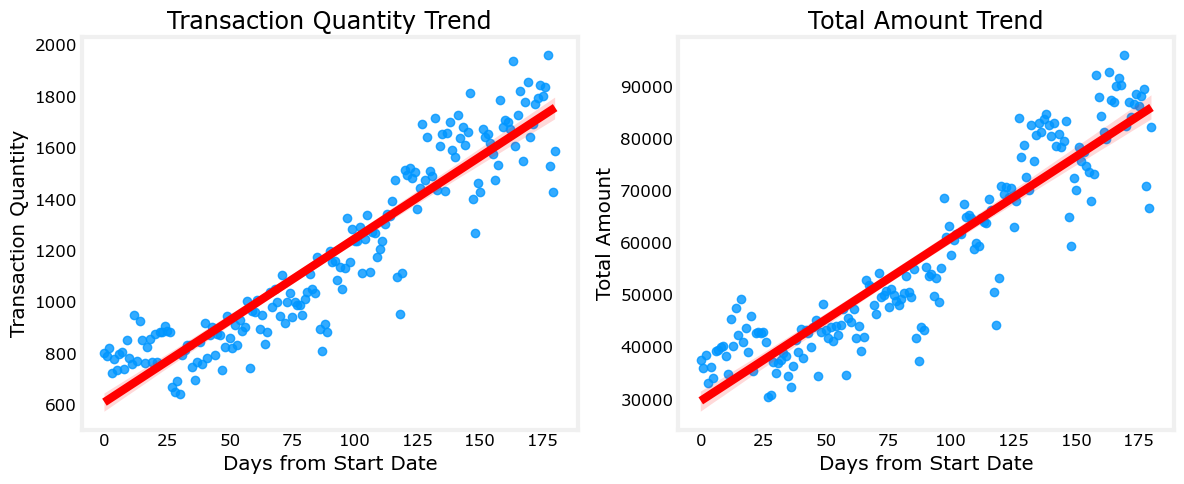

In [131]:
daily_sales['transaction_date'] = pd.to_datetime(daily_sales['transaction_date'])

# Convert 'transaction_date' to a numerical representation (e.g., number of days since the first date)
daily_sales['date_numeric'] = (daily_sales['transaction_date'] - daily_sales['transaction_date'].min()).dt.days

# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Plot the first chart
sns.regplot(x="date_numeric", y="transaction_qty", data=daily_sales, ax=axes[0], line_kws={"color": "red"})
axes[0].set_title('Transaction Quantity Trend')
axes[0].set_xlabel('Days from Start Date')
axes[0].set_ylabel('Transaction Quantity')

# Plot the second chart
sns.regplot(x="date_numeric", y="total_amount", data=daily_sales, ax=axes[1], line_kws={"color": "red"})
axes[1].set_title('Total Amount Trend')
axes[1].set_xlabel('Days from Start Date')
axes[1].set_ylabel('Total Amount')

plt.tight_layout()
plt.show()

Model development

We'll fit two regression lines, 1st one will try to predict transactions based on date and the 2nd will try to predict total amount (revenue) by date

Let's get our y_data (target) and our x_data (features)

In [133]:
daily_sales['date_numeric'] = (daily_sales['transaction_date'] - daily_sales['transaction_date'].min()).dt.days
y_data = daily_sales['transaction_qty']
x_data = daily_sales['date_numeric']

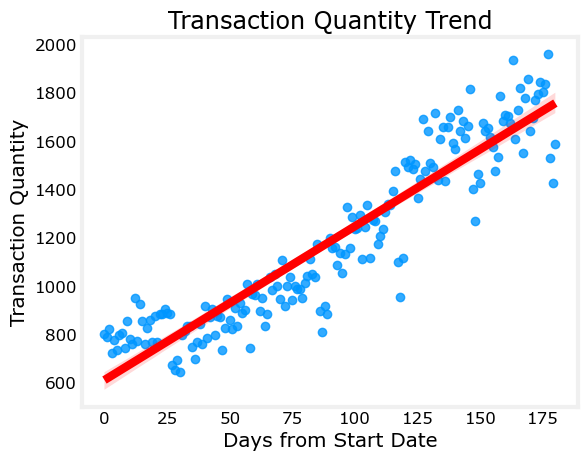

In [149]:
# Plot the chart
fig, ax = plt.subplots()

# Plot the data, passing the correct 'ax' object
sns.regplot(x='date_numeric', y='transaction_qty', data=daily_sales, ax=ax, line_kws={"color": "red"})

# Set labels and title on the 'ax' object
ax.set_title('Transaction Quantity Trend')
ax.set_xlabel('Days from Start Date')
ax.set_ylabel('Transaction Quantity')

plt.show()

Split the data into training and test sets. 80% training data and 20% test data

In [151]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.20, random_state=1)
print('number of x test samples :', x_test.shape)
print('number of x training samples:',x_train.shape)
print ('number of y training samples: ', y_train.shape)

number of x test samples : (37,)
number of x training samples: (144,)
number of y training samples:  (144,)


Let's fit our model and print the R^2 value

In [153]:
linear_model = LinearRegression()
#x must be a 2-D Matrix
linear_model.fit(x_train.values.reshape(-1, 1), y_train)

LinearRegression()

Let's calculate the R2 

In [155]:
linear_model.score(x_train.values.reshape(-1, 1), y_train)

0.8526947605462443

In [157]:
linear_model.score(x_test.values.reshape(-1, 1), y_test)

0.914551189895927

In [159]:
b = linear_model.intercept_
w = linear_model.coef_
print(f"w = {w:}, b = {b:0.2f}")

w = [6.39], b = 611.36


In [167]:
y_pred = linear_model.predict(x_train.values.reshape(-1, 1))

print("Prediction on training set:", y_pred)

x_test = np.array([[151]])
print(f"Predicted sales for day 151: {linear_model.predict(x_test)[0]:0.2f}")

Prediction on training set: [ 911.55 1154.25 1365.02 1550.25 1192.58  981.8  1281.99  860.45 1601.34
  892.39 1135.09  822.13  726.33  988.19 1441.67 1128.71 1575.8   688.
 1211.74 1077.61  790.19 1186.19 1492.76 1352.25 1454.44  719.94 1563.02
 1403.35 1371.41  694.39 1313.93 1422.51  898.77 1109.54  841.29 1722.7
 1690.76 1658.83 1729.08 1748.24 1626.89 1390.57 1090.38  745.49 1479.99
  624.13 1058.45 1703.54  649.68 1179.8   611.36 1671.6  1103.16 1026.51
  962.64 1652.44 1173.41 1288.38  905.16 1007.35 1084.   1198.96 1524.7
 1377.8  1396.96 1716.31 1339.48  675.23  828.52  815.74 1556.63  854.06
 1141.48 1754.63 1761.02  783.81 1250.06  758.26 1269.22 1039.29  668.84
 1588.57 1275.61 1416.12 1473.6  1665.21 1167.03 1237.28 1320.32 1697.15
 1639.67 1020.13  707.16  873.23 1677.99 1307.54 1122.32  943.48  777.42
 1096.77  886.    764.65  630.52 1582.18  924.32 1448.06 1709.92  802.97
 1384.19 1345.86 1620.5   662.46  994.58 1428.89  617.75  975.42  751.87
 1000.97 1013.74  656.07 17

In [171]:
y_pred = linear_model.predict(x_train.values.reshape(-1, 1))

x_test = np.array([[50]])
print(f"Predicted sales for day 50: {linear_model.predict(x_test)[0]:0.2f}")

Predicted sales for day 50: 930.71
